In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Carisurg_Triage_Test/EmergencyTriageDataset_Reduced_Dirty.csv')

In [59]:
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
display(df.head())

Dataset loaded: 2205 rows, 11 columns


,ID,Age,Gender,GCS,SBP,DBP,MAP,pulse,Temp,RR,Fio2
0,1,34,0,15.0,93,67.0,75.67,128.0,36.8,14.0,21.0
1,2,20,Male,15.0,130,90.0,103.33,80.0,37.0,16.0,21.0
2,3,77,Female,14.0,163,105.0,124.33,92.0,36.8,18.0,21.0
3,4,23,0,8.0,100,60.0,73.33,100.0,37.0,12.0,100.0
4,5,86,FEMALE,15.0,150,90.0,110.00,85.0,37.0,19.0,21.0


In [60]:
print("Statistical Summary:")
display(df.describe())

Statistical Summary:


,ID,Age,DBP,MAP,RR,Fio2
count,2205.000000,2205.000000,2183.000000,2183.000000,2183.000000,2183.000000
mean,1154.987755,61.829478,77.479615,93.912277,20.262254,25.019698
std,677.167364,18.485363,16.713289,19.006296,5.742333,10.144288
min,1.000000,18.000000,30.000000,39.330000,12.000000,21.000000
25%,577.000000,50.000000,70.000000,82.500000,17.000000,21.000000
50%,1135.000000,64.000000,78.000000,93.330000,18.000000,21.000000
75%,1703.000000,77.000000,87.000000,103.330000,21.000000,21.000000
max,2384.000000,98.000000,173.000000,185.000000,50.000000,100.000000


In [61]:
print("\nMissing values per column:")
print(df.isnull().sum())


Missing values per column:
ID         0
Age        0
Gender     0
GCS       22
SBP        0
DBP       22
MAP       22
pulse     22
Temp      22
RR        22
Fio2      22
dtype: int64


In [62]:
print("\nData types per column:")
print(df.dtypes)


Data types per column:
ID          int64
Age         int64
Gender     object
GCS        object
SBP        object
DBP       float64
MAP       float64
pulse      object
Temp       object
RR        float64
Fio2      float64
dtype: object


In [63]:
df['Gender'] = df['Gender'].astype(str).str.strip().str.upper()

In [64]:
gender_mapping = {
    'MALE': 1,
    'M': 1,
    '1': 1,
    'FEMALE': 0,
    'F': 0,
    '0': 0
}

In [65]:
df['Gender'] = df['Gender'].map(gender_mapping)
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])

In [66]:
df = df.rename(columns={'Gender': 'Gender_clean'})

In [67]:
df['DBP'] = pd.to_numeric(df['DBP'], errors='coerce')

In [68]:
df.loc[df['DBP'] < 30, 'DBP'] = pd.NA
df.loc[df['DBP'] > 150, 'DBP'] = pd.NA

In [69]:
df['DBP'] = df['DBP'].fillna(df['DBP'].median())

In [70]:
numeric_cols = ['SBP', 'pulse', 'Temp', 'RR', 'Fio2', 'Age', 'GCS', 'MAP']

In [71]:
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

In [72]:
for col in df.columns:

    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())

    else:
        mode_value = df[col].mode()
        if not mode_value.empty:
            df[col] = df[col].fillna(mode_value[0])
        else:
            df[col] = df[col].fillna("Unknown")

print("Remaining NaN values:")
print(df.isnull().sum())

print("Total remaining NaN:", df.isnull().sum().sum())

Remaining NaN values:
ID              0
Age             0
Gender_clean    0
GCS             0
SBP             0
DBP             0
MAP             0
pulse           0
Temp            0
RR              0
Fio2            0
dtype: int64
Total remaining NaN: 0


## Task 3 — Clinical Context: DBP

Diastolic Blood Pressure (DBP) is a vital sign that measures the pressure
exerted on the walls of the arteries when the heart is at rest between beats.
It is the lower number in a blood pressure reading, recorded in mmHg, and is
always reported alongside Systolic Blood Pressure, for example 120/80 mmHg.

**Normal clinical range:** 60 to 80 mmHg.

Values below 60 mmHg may indicate hypotension, meaning the body's organs are
not receiving adequate blood flow. Values consistently above 90 mmHg are
associated with hypertension, increasing the risk of stroke, heart failure,
and kidney disease.

In a triage setting, DBP is a critical indicator of haemodynamic stability.
A dangerously low DBP may signal shock or severe dehydration requiring
immediate intervention, while a significantly elevated DBP may indicate a
hypertensive crisis also demanding urgent attention. Clinicians use DBP
alongside other vital signs to classify patients by severity and prioritise
care accordingly.

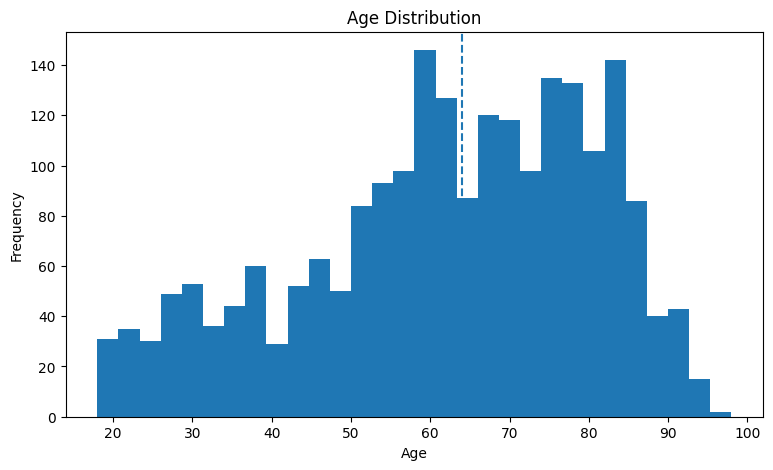

In [73]:
age_median = df['Age'].median()

plt.figure(figsize=(9,5))
plt.hist(df['Age'], bins=30)
plt.axvline(age_median, linestyle='--')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

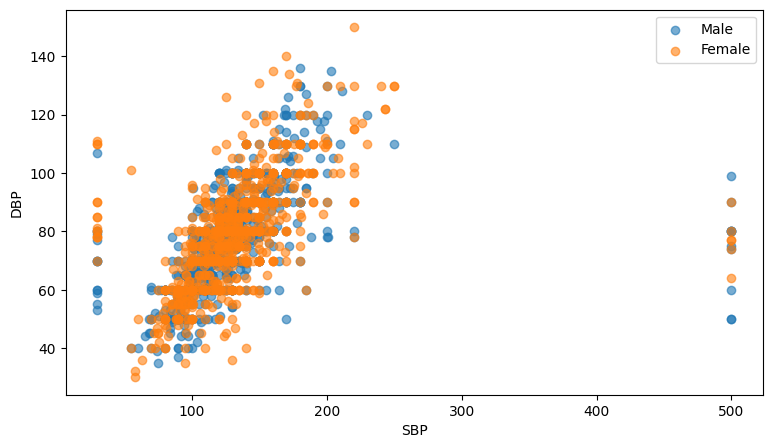

In [74]:
male = df[df['Gender_clean'] == 1]
female = df[df['Gender_clean'] == 0]

plt.figure(figsize=(9,5))
plt.scatter(male['SBP'], male['DBP'], alpha=0.6, label='Male')
plt.scatter(female['SBP'], female['DBP'], alpha=0.6, label='Female')
plt.xlabel('SBP')
plt.ylabel('DBP')
plt.legend()
plt.show()

In [75]:
def flag_at_risk(dbp_value):

    if dbp_value < 60 or dbp_value > 90:
        return 1
    return 0

df['at_risk'] = df['DBP'].apply(flag_at_risk)

print(df[['DBP', 'at_risk']].head())

print("Final Dataset Shape:", df.shape)
print("Final Remaining NaN:", df.isnull().sum().sum())

     DBP  at_risk
0   67.0        0
1   90.0        0
2  105.0        1
3   60.0        0
4   90.0        0
Final Dataset Shape: (2205, 12)
Final Remaining NaN: 0
